In [1]:
#import libraries
import netCDF4 as nc
from netCDF4 import Dataset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load the .nc file
model7 = xr.open_dataset(r'D:\zbatesno\CORDEX DATA\prec.rcp85.MPI-ESM-LR.WRF.day.NAM-22i.raw.nc')
#print(model7)

C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.0)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
# get the difference btwn 30 yrs of nc prec events >=3
# Select the subset of data for North Carolina using latitude and longitude coordinates
precipm7=model7['prec']
nc_prec_m7 = precipm7.sel(lat=slice(33.8, 37.0), lon=slice(-84.7, -75.4))

#GE 3in events
ge_3_m7=(nc_prec_m7 >= 76.2)

# >=3 prec events for the first 30 years
nc_precip_first_30_m7 = ge_3_m7.sel(time=slice('2021-01-01', '2050-01-01')).sum(dim='time')

# >=3 prec events for the last 30 years
nc_precip_last_30_m7 = ge_3_m7.sel(time=slice('2051-01-01', '2080-01-01')).sum(dim='time')

# Calculate the difference in projected >=3 prec events for selected intervals
nc_precip_diff_m7= nc_precip_last_30_m7 - nc_precip_first_30_m7

# Print the results
#print('Difference in projected >=3 prec events: ', nc_precip_diff_m7)

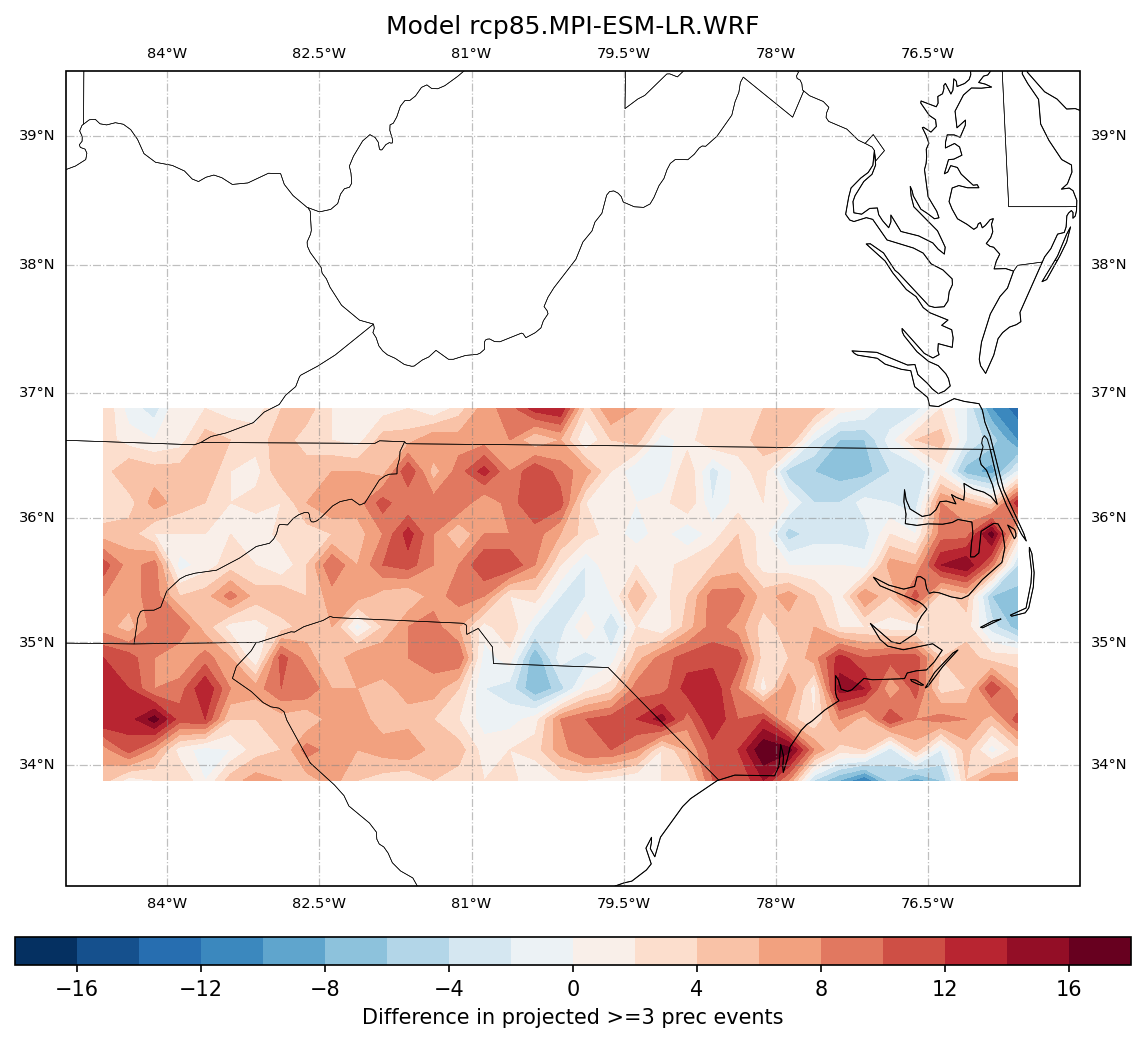

In [3]:
# Plot a map-like view of the difference field
# - Uses Cartopy if installed
# - Falls back to plain matplotlib if not

use_cartopy = False
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    use_cartopy = True
except Exception:
    use_cartopy = False

# Data bounds (for fallback + sanity)
data_lat_min, data_lat_max = float(freq_diff["lat"].min()), float(freq_diff["lat"].max())
data_lon_min, data_lon_max = float(freq_diff["lon"].min()), float(freq_diff["lon"].max())

# Expand map area for plotting 
map_lon_min, map_lon_max = -90, -75
map_lat_min, map_lat_max = 33, 40

absmax = float(np.nanmax(np.abs(freq_diff.values)))
if absmax == 0:
    absmax = 1.0

cmap = "RdBu_r"

plt.figure(figsize=(16, 9), dpi=150)

if use_cartopy:
    projection = ccrs.Mercator()
    data_crs = ccrs.PlateCarree()
    ax = plt.axes(projection=projection, frameon=True)

    gl = ax.gridlines(
        crs=data_crs,
        draw_labels=True,
        linewidth=0.6,
        color="gray",
        alpha=0.5,
        linestyle=":"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 7}
    gl.ylabel_style = {"size": 7}

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), lw=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.3)
    ax.add_feature(cfeature.STATES.with_scale("50m"), lw=0.3)

    ax.set_extent([map_lon_min, map_lon_max, map_lat_min, map_lat_max], crs=data_crs)

    # SIMPLE smoothing: more contour levels (reduces "pointy" look)
    freq_diff.plot.contourf(
        ax=ax,
        transform=data_crs,
        levels=61,  # <- changed from 21 to 61
        cmap=cmap,
        vmin=-absmax,
        vmax=absmax,
        cbar_kwargs={
            "orientation": "horizontal",
            "shrink": 0.6,
            "pad": 0.05,
            "aspect": 40,
            "label": "Difference in projected ≥3-inch days (late − early)"
        },
    )

    plt.title(f"Model {MODEL_LABEL}")

else:
    ax = plt.gca()
    ax.grid(True, linewidth=0.5, alpha=0.35, linestyle=":")

    plot_lon_min = max(map_lon_min, data_lon_min)
    plot_lon_max = min(map_lon_max, data_lon_max)
    plot_lat_min = max(map_lat_min, data_lat_min)
    plot_lat_max = min(map_lat_max, data_lat_max)

    if plot_lon_min >= plot_lon_max or plot_lat_min >= plot_lat_max:
        plot_lon_min, plot_lon_max = data_lon_min, data_lon_max
        plot_lat_min, plot_lat_max = data_lat_min, data_lat_max

    freq_plot = freq_diff.sel(
        lon=slice(plot_lon_min, plot_lon_max),
        lat=slice(plot_lat_min, plot_lat_max)
    )

    # SIMPLE smoothing: more contour levels (reduces "pointy" look)
    freq_plot.plot.contourf(
        ax=ax,
        levels=61,  # <- changed from 21 to 61
        cmap=cmap,
        vmin=-absmax,
        vmax=absmax,
        cbar_kwargs={"label": "Difference in projected ≥3-inch days (late − early)"},
    )

    ax.set_xlim(plot_lon_min, plot_lon_max)
    ax.set_ylim(plot_lat_min, plot_lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.title(f"Projected change in ≥3-inch event-days (no-basemap fallback)\nModel: {MODEL_LABEL}")

plt.savefig(OUT_MAP_PNG, bbox_inches="tight")
plt.show()
print("Saved map:", OUT_MAP_PNG)
print("Cartopy used:", use_cartopy)
